# **Project Name**    -



##### **Project Type**    - **Case Study :** **Walmart customer purchase behaviour against the gender**
**Using Confidence Interval and Central Limit Theorem**

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions.**

**They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).**

In [ ]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read the file

df = pd.read_csv('/content/walmart_data.csv')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
df.shape

(550068, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [ ]:
df.describe()

# 75% of purchase is 12054.00 and max is 23961.00, so there could be outliers

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [ ]:
#check for duplicates

df[df.duplicated()].shape # No duplicates

(0, 10)

**Analyzing the gender column**

In [ ]:
df['Gender'].value_counts()

,count
Gender,
M,414259
F,135809


Male transactions are more than women but single person can make multiple transactions, so we need to check the unique count of transactions for male and female.

In [ ]:
df.groupby("Gender")['User_ID'].nunique()

,User_ID
Gender,
F,1666
M,4225


We can confidently say 'M' Male transactions are more.

In [ ]:
df.groupby("Gender")['Purchase'].describe().T


Gender,F,M
count,135809.000000,414259.00000
mean,8734.565765,9437.52604
std,4767.233289,5092.18621
min,12.000000,12.00000
25%,5433.000000,5863.00000
50%,7914.000000,8098.00000
75%,11400.000000,12454.00000
max,23959.000000,23961.00000


The average(mean) for F female is 8734 and M male is 9437

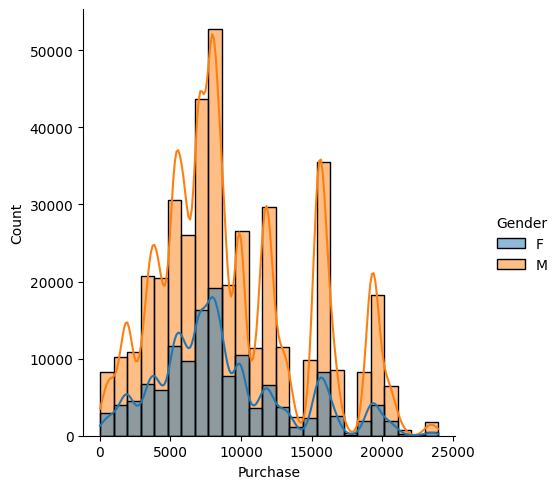

In [ ]:
sns.displot(x='Purchase', data = df, bins = 25, hue = 'Gender', kde = True)

Spending pattern is more of same for male and female. it is male doing more transactions.

From this we need to distinguish between Male and Female, so we will perform Central Limit Theorem (CLT).

CLT --> mean of sample means = mean of population means

The **Central Limit Theorem (CLT)** is important because it helps us study and compare large groups of people, even when the original data is messy or not normally distributed.

In simple words:

People do not all spend money in the same pattern. Some customers spend very little, while a few spend a huge amount. Because of this, the individual purchase data may not follow a normal (bell-shaped) distribution.

But CLT says that:

 **If we take many large samples from the population and calculate their average purchase amounts, those averages will form a normal distribution.**

This is very useful because most statistical tests (like the t-test) work best when data is approximately normal.

So, in this case, CLT allows us to:

* Compare the **average spending of male and female customers**
* Use statistical tests confidently
* Decide whether the difference in spending is real or just due to random chance
* Apply the results from the sample data to the larger population of millions of customers

In short, CLT gives us the confidence to make conclusions about the spending behavior of all customers using only sample data.


In [ ]:
#Implemeting Central Limit Theorem (CLT)
# for example we take 300 samples

df.sample(300).groupby('Gender')['Purchase'].describe()

# Anything more than 30 is a good sample

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,65.0,8220.892308,4027.993003,757.0,5880.0,7977.0,9856.0,20237.0
M,235.0,9288.536170,5056.519556,49.0,5910.5,7999.0,11955.5,23885.0


Performing Random Sampling

In [43]:
# taking sample of 30,000 sample size

male_spending_means = [df[df['Gender']== 'M']['Purchase'].sample(30000).mean() for i in range(1000)]

female_sample_means = [df[df['Gender']=='F']['Purchase'].sample(30000).mean() for i in range(1000)]


### Analyzing Sample Means

In [44]:
male_mean_of_sample_means = np.mean(male_spending_means)
female_mean_of_sample_means = np.mean(female_sample_means)

print(f"Mean of Male Sample Means: {male_mean_of_sample_means:.2f}")
print(f"Mean of Female Sample Means: {female_mean_of_sample_means:.2f}")


Mean of Male Sample Means: 9436.16
Mean of Female Sample Means: 8734.96


#### Distribution of Sample Means

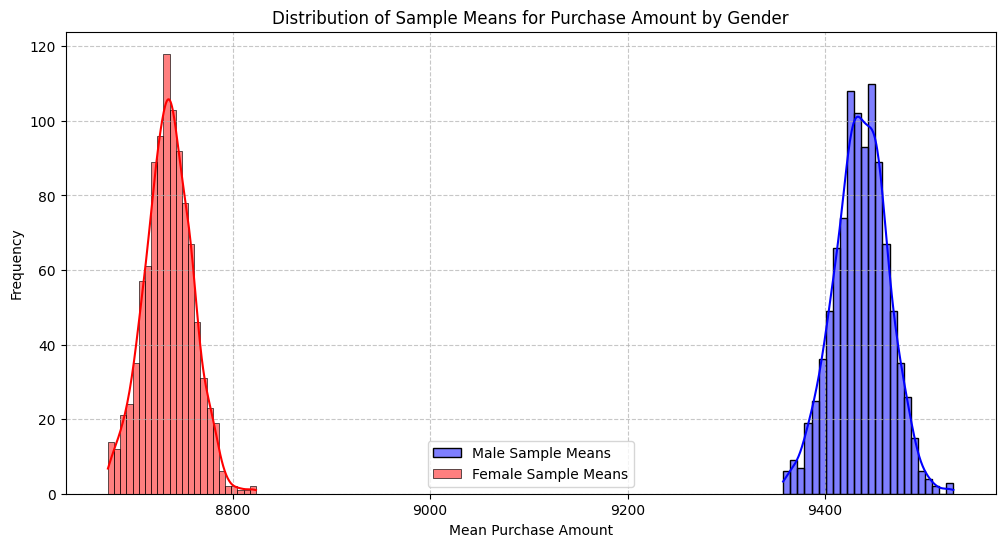

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(male_spending_means, color='blue', label='Male Sample Means', kde=True)
sns.histplot(female_sample_means, color='red', label='Female Sample Means', kde=True)
plt.title('Distribution of Sample Means for Purchase Amount by Gender')
plt.xlabel('Mean Purchase Amount')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Calculating Confidence Intervals (95% Confidence Level)

In [46]:
z = 1.96 # For a 95% confidence interval

std_err_male = np.std(male_spending_means)
std_err_female = np.std(female_sample_means)

lower_lim_male = male_mean_of_sample_means - z * std_err_male
upper_lim_male = male_mean_of_sample_means + z * std_err_male

lower_lim_female = female_mean_of_sample_means - z * std_err_female
upper_lim_female = female_mean_of_sample_means + z * std_err_female

print(f"Male Purchase Amount 95% Confidence Interval: ({lower_lim_male:.2f}, {upper_lim_male:.2f})")
print(f"Female Purchase Amount 95% Confidence Interval: ({lower_lim_female:.2f}, {upper_lim_female:.2f})")


Male Purchase Amount 95% Confidence Interval: (9382.13, 9490.19)
Female Purchase Amount 95% Confidence Interval: (8687.60, 8782.33)


#### Visualizing Confidence Intervals

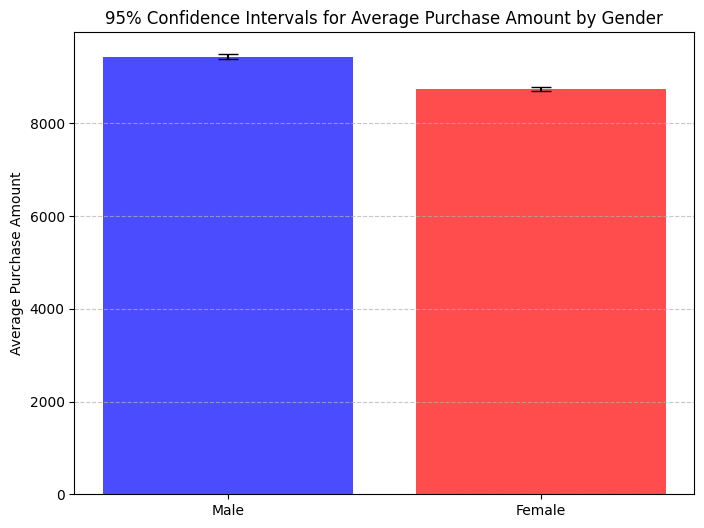

In [47]:
means = [male_mean_of_sample_means, female_mean_of_sample_means]
errors = [z * std_err_male, z * std_err_female]
genders = ['Male', 'Female']

plt.figure(figsize=(8, 6))
plt.bar(genders, means, yerr=errors, capsize=7, color=['blue', 'red'], alpha=0.7)
plt.title('95% Confidence Intervals for Average Purchase Amount by Gender')
plt.ylabel('Average Purchase Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Conclusion from CLT Analysis

From the confidence intervals and distributions, we can observe whether there is a statistically significant difference in the average purchase amounts between male and female customers. If the confidence intervals do not overlap, it suggests a significant difference.

## Recommendations for Walmart

Based on the analysis of customer purchase behavior using the Central Limit Theorem (CLT), here are some simple business recommendations:

### 1. Men Spend More on Average

The analysis shows that male customers spend more on average than female customers during Black Friday sales. Since the confidence intervals for male and female spending do not overlap, the difference is statistically significant.

**Recommendation:**

* Walmart can create more targeted promotions for male customers to maximize sales.
* At the same time, Walmart can introduce special offers, bundles, discounts, or loyalty rewards to encourage higher spending among female customers.

---

### 2. More Male Customers and Higher Spending

The data also shows that there are more unique male customers, and they also spend more per transaction compared to female customers.

**Recommendation:**

* Walmart should focus on attracting more female shoppers through personalized campaigns and marketing.
* They can also encourage repeat purchases from existing female customers using reward points, membership benefits, or seasonal offers.

---

### 3. Analyze Product Categories Further

The current analysis only compares total spending between men and women. It does not show which products they prefer.

**Recommendation:**

* Walmart should analyze spending by product category for each gender.
* This can help identify:

  * Which products are popular among men and women
  * Cross-selling opportunities
  * Better personalized recommendations
  * More effective marketing campaigns

---

### Overall Conclusion

The analysis helps Walmart better understand customer spending behavior. Using these insights, Walmart can improve marketing strategies, increase customer engagement, and boost overall sales.
